# Model Analysis: PRAE

Diagnostic analysis of the trained **Probabilistic Robust Autoencoder** (§5.1.3 of the report):

1. Gate parameter $\mu_i$ distribution — fraction with $\mu < 0.1$ (anomalous).
2. Anomaly identification via the $\mu < 0.1$ criterion.
3. Reconstruction error distribution (gated-in vs. gated-out training views).
4. Test-time anomaly scores: $\sum (x - \hat{x})^2$ per sample.
5. RFDR online thresholding demonstration.
6. Score distribution across test days.

In [9]:
import os, sys, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences, load_processed
from detection.models.transformer import BottleneckTransformer
from detection.models.prae import PRAE
from detection.thresholds.rfdr import RollingFalseDiscoveryRate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Load the Trained PRAE Model

Reconstruct the architecture to match the saved checkpoint, then load the weights.

In [10]:
# ── Configuration ──────────────────────────────────────────────
TRAIN_YEAR = "2015"  # "2015" or "2017"
RESULTS_DIR = os.path.join("..", "results", str(TRAIN_YEAR))
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")

SEQ_LENGTH = 25
BATCH_SIZE = 512

LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [("bid","price"),("bid","volume"),("ask","price"),("ask","volume")]
]

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[22], FILES[23], FILES[24], FILES[25], FILES[26]]

# ── Architecture (must match training) ────────────────────────
NUM_FEATURES = 89
MODEL_DIM = 128
NUM_HEADS = 8
NUM_LAYERS = 6
REPRESENTATION_DIM = 128
DIM_FEEDFORWARD = 512
PRAE_SIGMA = 0.5

# RFDR thresholding
RFDR_WINDOW = 500
RFDR_ALPHA = 0.05

# ── Load model ────────────────────────────────────────────────
weights_path = os.path.join(RESULTS_DIR, "prae_weights.pth")
state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
num_train_samples = state_dict["mu"].shape[0]
print(f"Saved mu has {num_train_samples:,} entries (training samples)")

backbone = BottleneckTransformer(
    num_features=NUM_FEATURES,
    model_dim=MODEL_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    representation_dim=REPRESENTATION_DIM,
    sequence_length=SEQ_LENGTH,
    dim_feedforward=DIM_FEEDFORWARD,
)
model = PRAE(
    backbone_model=backbone,
    num_train_samples=num_train_samples,
    lambda_reg=1.0,
    sigma=PRAE_SIGMA,
)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

# ── Load feature names & scaler ───────────────────────────────
feat_path = os.path.join(RESULTS_DIR, "prae_features.txt")
with open(feat_path) as f:
    feat_names = [line.strip() for line in f if line.strip()]
scaler_path = os.path.join(RESULTS_DIR, "prae_scaler.pkl")
scaler = joblib.load(scaler_path)

print(f"Training year : {TRAIN_YEAR}")
print(f"Features      : {len(feat_names)}")
print(f"Test files    : {[os.path.basename(f) for f in TEST_FILES]}")

Saved mu has 61,877 entries (training samples)
Training year : 2015
Features      : 89
Test files    : ['2010-02-02-TOTF.PA-book.parquet', '2010-02-03-TOTF.PA-book.parquet', '2010-02-04-TOTF.PA-book.parquet', '2010-02-05-TOTF.PA-book.parquet', '2010-02-08-TOTF.PA-book.parquet']


## 2. $\mu$ Distribution

Each training sample $i$ has a learned gate parameter $\mu_i$.  
- **$\mu_i \approx 1$** → the model can reconstruct the sample well (normal).  
- **$\mu_i \approx 0$** → the sample is hard to reconstruct and down-weighted (anomalous).

We use $\mu_i < 0.1$ as the anomaly threshold, as defined in the original paper.

mu summary statistics
Count : 61,877
Mean  : 0.5018
Std   : 0.0005
Min   : 0.4981
Max   : 0.5025
Median: 0.5020


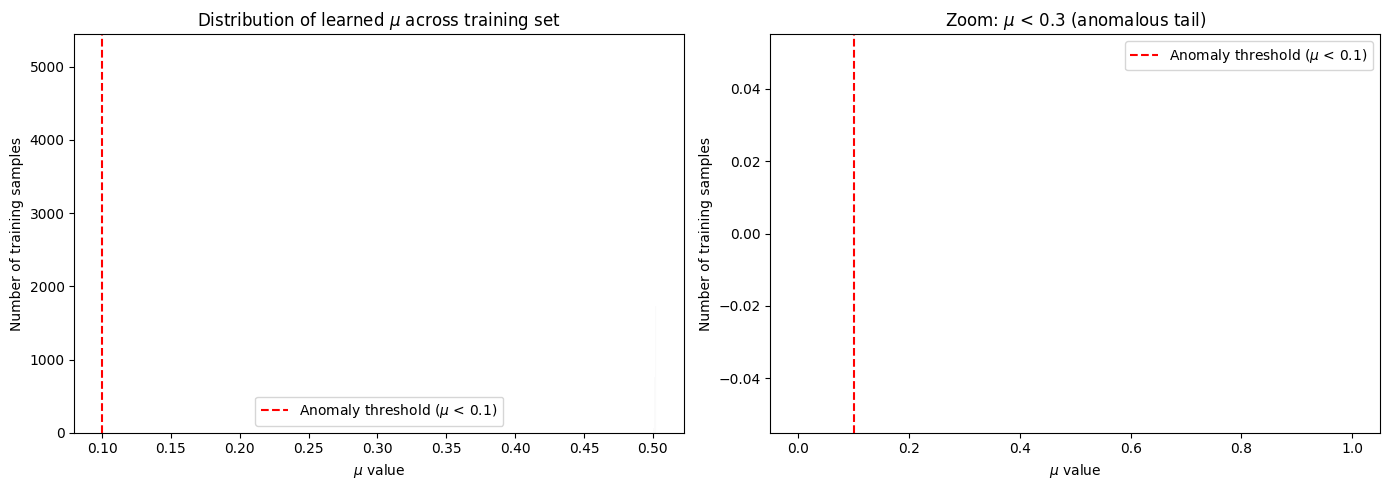

In [11]:
mu_values = model.mu.detach().cpu().numpy()

# Summary statistics
print("mu summary statistics")
print(f"Count : {len(mu_values):,}")
print(f"Mean  : {mu_values.mean():.4f}")
print(f"Std   : {mu_values.std():.4f}")
print(f"Min   : {mu_values.min():.4f}")
print(f"Max   : {mu_values.max():.4f}")
print(f"Median: {np.median(mu_values):.4f}")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(mu_values, bins=100, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0.1, color="red", linestyle="--", linewidth=1.5, label="Anomaly threshold ($\mu$ < 0.1)")
axes[0].set_xlabel("$\mu$ value")
axes[0].set_ylabel("Number of training samples")
axes[0].set_title("Distribution of learned $\mu$ across training set")
axes[0].legend()

# Low-mu tail
low_mu = mu_values[mu_values < 0.3]
axes[1].hist(low_mu, bins=60, color="tomato", edgecolor="white", alpha=0.85)
axes[1].axvline(0.1, color="red", linestyle="--", linewidth=1.5, label="Anomaly threshold ($\mu$ < 0.1)")
axes[1].set_xlabel("$\mu$ value")
axes[1].set_ylabel("Number of training samples")
axes[1].set_title("Zoom: $\mu$ < 0.3 (anomalous tail)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Anomaly Identification ($\mu < 0.1$)

Anomaly threshold : $\mu$ < 0.1
Total training samples : 61,877
Anomalies identified  : 0
Anomaly percentage    : 0.00%
Normal percentage     : 100.00%


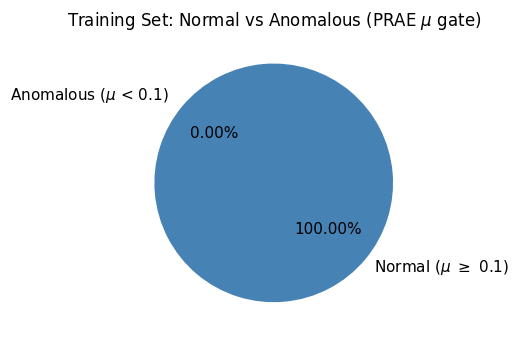

In [12]:
ANOMALY_THRESHOLD = 0.1

anomaly_mask = mu_values < ANOMALY_THRESHOLD
n_anomalies = anomaly_mask.sum()
n_total = len(mu_values)
pct_anomalies = 100.0 * n_anomalies / n_total

print(f"Anomaly threshold : $\mu$ < {ANOMALY_THRESHOLD}")
print(f"Total training samples : {n_total:,}")
print(f"Anomalies identified  : {n_anomalies:,}")
print(f"Anomaly percentage    : {pct_anomalies:.2f}%")
print(f"Normal percentage     : {100.0 - pct_anomalies:.2f}%")

fig, ax = plt.subplots(figsize=(5, 5))
labels = [f"Normal ($\mu$ $\geq$ {ANOMALY_THRESHOLD})", f"Anomalous ($\mu$ < {ANOMALY_THRESHOLD})"]
sizes = [n_total - n_anomalies, n_anomalies]
colors = ["steelblue", "tomato"]
explode = (0, 0.05)

wedges, texts, autotexts = ax.pie(
    sizes, explode=explode, labels=labels, colors=colors,
    autopct="%1.2f%%", startangle=140, textprops={"fontsize": 11},
)
ax.set_title("Training Set: Normal vs Anomalous (PRAE $\mu$ gate)")
plt.tight_layout()
plt.show()

## 4. Reconstruction Error: Gated-In vs. Gated-Out (Training Set)

Compare reconstruction error for training samples the model considers **normal** ($\mu \geq 0.1$, gated-in)
vs. **anomalous** ($\mu < 0.1$, gated-out). The PRAE loss down-weights anomalous samples, so they should
have significantly higher reconstruction error.

=== Reconstruction Error (first 5 training days) ===
  Gated-in  (μ ≥ 0.1): 0 samples,  mean = nan,  std = nan
  Gated-out (μ < 0.1): 0 samples in this subset


IndexError: index -1 is out of bounds for axis 0 with size 0

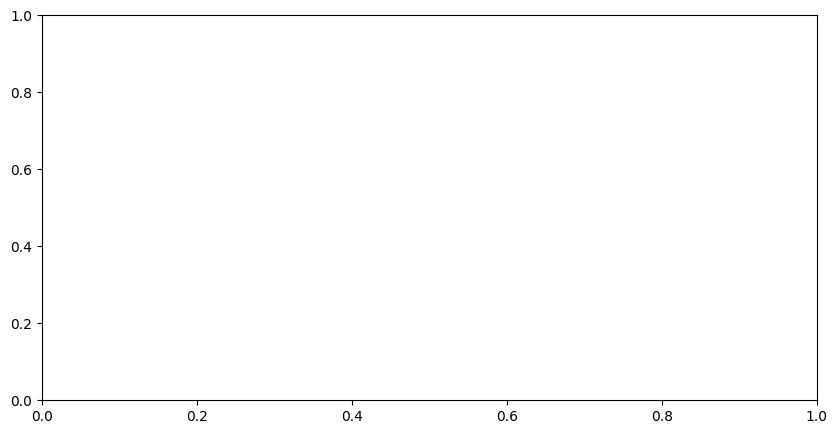

In [13]:
# Load a subset of training files and compute per-sample rec error,
# then correlate with the stored mu values using training-set indices.
YEAR_FILES = sorted(glob.glob(os.path.join(DATA_DIR, f"{TRAIN_YEAR}*.parquet")))
NUM_HOLDOUT = 12
TRAIN_FILE_LIST = YEAR_FILES[:len(YEAR_FILES) - NUM_HOLDOUT]
N_SUBSET = min(5, len(TRAIN_FILE_LIST))  # first 5 training days for speed

rec_errors_gated_in = []
rec_errors_gated_out = []
mu_idx = 0  # running index into model.mu

for tf in TRAIN_FILE_LIST[:N_SUBSET]:
    _, feat_d = load_processed(tf, "xltime", LOB_COLUMNS)
    for c in feat_names:
        if c not in feat_d.columns:
            feat_d[c] = 0.0
    feat_d = feat_d[feat_names]
    sc = scaler.transform(feat_d.values.astype(np.float32)).astype(np.float32)
    seqs = create_sequences(sc, SEQ_LENGTH)
    if len(seqs) == 0:
        continue

    x_t = torch.tensor(seqs, dtype=torch.float32)
    ds = TensorDataset(x_t, x_t)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    day_errs = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(DEVICE)
            rec, _ = model(x, training=False)
            err = torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim()))).cpu().numpy()
            day_errs.append(err)
    day_errs = np.concatenate(day_errs)

    # Corresponding mu values
    end_idx = mu_idx + len(day_errs)
    if end_idx <= len(mu_values):
        day_mu = mu_values[mu_idx:end_idx]
        rec_errors_gated_in.append(day_errs[day_mu >= 0.1])
        rec_errors_gated_out.append(day_errs[day_mu < 0.1])
    mu_idx = end_idx
    del x_t, ds, loader

err_in = np.concatenate(rec_errors_gated_in) if rec_errors_gated_in else np.array([])
err_out = np.concatenate(rec_errors_gated_out) if rec_errors_gated_out else np.array([])

print(f"=== Reconstruction Error (first {N_SUBSET} training days) ===")
print(f"  Gated-in  (μ ≥ 0.1): {len(err_in):,} samples,  mean = {err_in.mean():.4f},  std = {err_in.std():.4f}")
if len(err_out) > 0:
    print(f"  Gated-out (μ < 0.1): {len(err_out):,} samples,  mean = {err_out.mean():.4f},  std = {err_out.std():.4f}")
    print(f"  Ratio out/in         : {err_out.mean() / err_in.mean():.2f}×")
else:
    print("  Gated-out (μ < 0.1): 0 samples in this subset")

fig, ax = plt.subplots(figsize=(10, 5))
clip_hi = np.percentile(np.concatenate([err_in, err_out]) if len(err_out) > 0 else err_in, 99)
ax.hist(err_in, bins=150, alpha=0.7, color="steelblue", label=f"Gated-in (μ ≥ 0.1, n={len(err_in):,})",
        density=True, range=(0, clip_hi))
if len(err_out) > 0:
    ax.hist(err_out, bins=150, alpha=0.7, color="tomato", label=f"Gated-out (μ < 0.1, n={len(err_out):,})",
            density=True, range=(0, clip_hi))
ax.set_xlabel("Reconstruction Error $\\sum(x - \\hat{x})^2$")
ax.set_ylabel("Density")
ax.set_title("Reconstruction Error: Gated-In vs. Gated-Out (Training)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Test-Time Anomaly Scores

At inference the PRAE score is simply $\sum (x - \hat{x})^2$ (sum of squared reconstruction error, no gate).
Anomaly detection uses **RFDR** (Rolling False Discovery Rate) on these scores.

In [14]:
# Score a single test file to show distribution + RFDR demo
TEST_FILE = TEST_FILES[0]
_, feat_test = load_processed(TEST_FILE, "xltime", LOB_COLUMNS)
for c in feat_names:
    if c not in feat_test.columns:
        feat_test[c] = 0.0
feat_test = feat_test[feat_names]

sc_test = scaler.transform(feat_test.values.astype(np.float32)).astype(np.float32)
seqs_test = create_sequences(sc_test, SEQ_LENGTH)

x_t = torch.tensor(seqs_test, dtype=torch.float32)
ds = TensorDataset(x_t, x_t)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

test_scores = []
model.eval()
with torch.no_grad():
    for batch in loader:
        x = batch[0].to(DEVICE)
        rec, _ = model(x, training=False)
        err = torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim()))).cpu().numpy()
        test_scores.append(err)
test_scores = np.concatenate(test_scores)

print(f"=== Test-Time Scores on {os.path.basename(TEST_FILE)} ===")
print(f"  Samples  : {len(test_scores)}")
print(f"  Mean     : {test_scores.mean():.4f}")
print(f"  Std      : {test_scores.std():.4f}")
print(f"  Median   : {np.median(test_scores):.4f}")
print(f"  P95      : {np.percentile(test_scores, 95):.4f}")
print(f"  P99      : {np.percentile(test_scores, 99):.4f}")
print(f"  Max      : {test_scores.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

p99 = np.percentile(test_scores, 99.5)
axes[0].hist(test_scores, bins=200, color="steelblue", edgecolor="white", alpha=0.85,
             density=True, range=(0, p99))
axes[0].set_xlabel("Reconstruction Error $\\sum(x-\\hat{x})^2$")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Score distribution — {os.path.basename(TEST_FILE)}")
axes[0].axvline(np.percentile(test_scores, 99), color="red", linestyle="--",
                label=f"P99 = {np.percentile(test_scores, 99):.2f}")
axes[0].legend(fontsize=8)

# Time series
axes[1].plot(test_scores, linewidth=0.3, alpha=0.7, color="steelblue")
axes[1].set_xlabel("Sequence index")
axes[1].set_ylabel("Reconstruction Error")
axes[1].set_title("Score time series")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 6. RFDR Online Thresholding

Apply the **Rolling False Discovery Rate** (Benjamini-Hochberg on a rolling window of z-scores)
to the test scores. This is the PRAE threshold method used in test.py.

In [ ]:
rfdr = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)

rfdr_preds = np.zeros(len(test_scores), dtype=int)
rfdr_thresholds = np.full(len(test_scores), np.nan)

for i, s in enumerate(test_scores):
    is_anom, thresh = rfdr.process_new_score(float(s))
    rfdr_preds[i] = int(is_anom)
    rfdr_thresholds[i] = thresh

n_flag = rfdr_preds.sum()
print(f"=== RFDR on {os.path.basename(TEST_FILE)} ===")
print(f"  Window    : {RFDR_WINDOW}")
print(f"  Alpha     : {RFDR_ALPHA}")
print(f"  Flagged   : {n_flag} / {len(rfdr_preds)} ({100*n_flag/len(rfdr_preds):.2f}%)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_scores, linewidth=0.3, alpha=0.5, color="steelblue", label="Score")
ax.plot(rfdr_thresholds, linewidth=0.8, color="orange", alpha=0.8, label="RFDR threshold")

anom_idx = np.where(rfdr_preds == 1)[0]
if len(anom_idx) > 0:
    ax.scatter(anom_idx, test_scores[anom_idx], s=6, color="red", zorder=3, label=f"Anomaly (n={n_flag})")

ax.set_xlabel("Sequence index")
ax.set_ylabel("Reconstruction Error")
ax.set_title(f"RFDR thresholding — {os.path.basename(TEST_FILE)}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Score Distribution Across Test Days

Run PRAE + RFDR scoring on all test files. Aggregate statistics per day.

In [ ]:
day_results = []
all_scores_agg = []

for tf in TEST_FILES:
    day_name = os.path.basename(tf)
    _, feat_d = load_processed(tf, "xltime", LOB_COLUMNS)
    for c in feat_names:
        if c not in feat_d.columns:
            feat_d[c] = 0.0
    feat_d = feat_d[feat_names]
    sc = scaler.transform(feat_d.values.astype(np.float32)).astype(np.float32)
    seqs = create_sequences(sc, SEQ_LENGTH)
    if len(seqs) == 0:
        continue

    x_t = torch.tensor(seqs, dtype=torch.float32)
    ds = TensorDataset(x_t, x_t)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    scores_day = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(DEVICE)
            rec, _ = model(x, training=False)
            err = torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim()))).cpu().numpy()
            scores_day.append(err)
    scores_day = np.concatenate(scores_day)
    all_scores_agg.append(scores_day)

    # RFDR per day
    rfdr_day = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
    n_flag = 0
    for s in scores_day:
        is_anom, _ = rfdr_day.process_new_score(float(s))
        n_flag += int(is_anom)

    day_results.append({
        "Day": day_name,
        "N": len(scores_day),
        "Mean Score": f"{scores_day.mean():.4f}",
        "Std Score": f"{scores_day.std():.4f}",
        "P99 Score": f"{np.percentile(scores_day, 99):.4f}",
        "Max Score": f"{scores_day.max():.4f}",
        "RFDR Flagged": n_flag,
        "Rate (%)": f"{100 * n_flag / len(scores_day):.2f}",
    })
    del feat_d, x_t, ds, loader

df_summary = pd.DataFrame(day_results)
print(df_summary.to_string(index=False))

# Aggregate histogram
all_sc = np.concatenate(all_scores_agg)
fig, ax = plt.subplots(figsize=(10, 4.5))
p99 = np.percentile(all_sc, 99.5)
ax.hist(all_sc, bins=300, color="steelblue", edgecolor="white", alpha=0.85,
        density=True, range=(0, p99))
ax.set_xlabel("Reconstruction Error $\\sum(x-\\hat{x})^2$")
ax.set_ylabel("Density")
ax.set_title(f"Aggregate score distribution — {len(TEST_FILES)} test days ({TRAIN_YEAR})")
ax.axvline(np.percentile(all_sc, 99), color="red", linestyle="--",
           label=f"P99 = {np.percentile(all_sc, 99):.2f}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

n_total = len(all_sc)
n_flag_total = sum(int(r["RFDR Flagged"]) for r in day_results)
print(f"\nAggregate: {n_total} samples, {n_flag_total} RFDR-flagged ({100*n_flag_total/n_total:.2f}%)")